In [ ]:
import numpy as np                # Numerical programming package
import matplotlib.pyplot as plt   # Plotting library
import scipy as sci               # Scientific computing library
import numba as nb                # Just-In-Time (JIT) compiler
from tqdm import tqdm             # A smart progress bar
                                  # Fun fact from tqdm documentation: tqdm means "progress"
                                  # in Arabic (taqadum, تقدّم) and is an abbreviation for
                                  #"I love you so much" in Spanish (te quiero demasiado).

# [CORRECTION, SOLVED] Lesson 2, exercise 6: solve 1D Poisson's equation with Neumann & Dirichlet boundary conditions using the SOR method
In this exercise we will use the SOR method to solve the 1D Poisson's equation (note that we have dropped $\epsilon_0$ to simplify the equation, which can be done by choosing an opportune system of units):

$ \dfrac{ \partial^2 \phi(x)}{\partial x^2}  = - \rho(x) $

Let's suppose that we want to solve this problem in the interval $[0, 5]$ with the Neumann boundary condition:

$\dfrac{\partial \phi}{\partial x}(0) = 0$

which corresponds to zero electric field at the left boundary.
Note that, thanks to the divergence theorem, the derivative on the right boundary is automatically given by:

$\dfrac{\partial \phi}{\partial x}(5) - \dfrac{\partial \phi}{\partial x}(0) = -\int_{0}^{5} \rho(x)$ dx

However, we need one last condition to make our system of equations fully determined. Indeed, as it is now, if $\phi_A$ is a valid solution, then also $\phi_B = \phi_A + c$ is a valid solution (where $c$ is an arbitrary real constant). One option is simply to impose a Dirichlet boundary condition on the right boundary:

$\phi(5) = \phi_0$

How can we impose the Neumann boundary condition on the left boundary? We can set $\phi_0$ in such a way that the (second-order accurate) finite difference approximation of the first order derivatives at $\phi_0$ has the value dictated by the Neumann boundary condition. If we have a look [here](https://en.wikipedia.org/wiki/Finite_difference_coefficient) we can see that the right expressions for the (second order accurate) forward finite difference approximation of the first order derivative is:

- Forward:  $\dfrac{\partial f}{\partial x} (x_i) \approx \dfrac{- 3 f(x_i) + 4 f(x_{i+1}) - f(x_{i+2})}{2 \Delta x} $

Use this information to complete the code in `poisson_neumann_dirichlet_SOR_compiled` and run the code blocks below to check the result.

In [ ]:
@nb.jit
def poisson_neumann_dirichlet_SOR_compiled (rho, phi0, dx, neumann_boundary_left, dirichlet_boundary_right, tolerance, max_iter, omega):
    """
    This is a Poisson's solver based on the Successive Over Relaxation (SOR) method
    enforcing Neumann boundary conditions on the left boundary and Dirichlet boundary conditions on the
    right boundary. The method stops if tolerance is met or if the max_iter
    number of iterations is attained.

    Parameters
    ----------
    rho : array of floats
        N-components vector of the density rho. Note that rho[0] and rho[N-1] are ignored by the algorithm.
    phi0 : array of floats
        N-components vector, initial guess of the potential
    dx : float
        spatial step size
    neumann_boundary_left : float
        the Neumann boundary condition on the left boundary
    dirichlet_boundary_right : float
        the Dirichlet boundary condition on the right boundary
    tolerance : float
        maximum accepted value of the residual norm
    max_iter : integer
        maximum number of iterations
    omega : float
        the omega parameter used in the SOR method

    Returns
    -------
    phi : array of floats
        the computed potential
    it : integer
        the number of iterations required to compute the potential
    """

    N = np.shape(phi0)[0] # size of the vectors phi and rho

    phi = np.copy(phi0) # deep copy of the initial guess x0: we don't want to overwrite it!

    # residual R
    R = np.zeros(N)
    norm_R = 1.0

    for it in range(max_iter):

        # enforce boundary conditions for phi[0]
        #### SOLUTION ##########
        phi[0] = (-2 * neumann_boundary_left * dx + 4*phi[1] -  phi[2])/3.0
        ########################

        #### SOLUTION ###
        for i in range(1,N-1):
            phi[i] = (1.0-omega)*phi[i] + omega* (+rho[i]*(dx**2) + phi[i-1] + phi[i+1] )/2.0

        for i in range(1,N-1):
            R[i] = (phi[i-1] - 2*phi[i] + phi[i+1]) + rho[i]*(dx**2)

        norm_R = np.linalg.norm(R)
        ##################

        #### SOLUTION ##########
        phi[N-1] = dirichlet_boundary_right
        ########################

        if (norm_R < tolerance):
            return phi, it

    raise RuntimeError("Solver failed to converge!")

    return phi, -1

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def do_poisson_neumann_dirichlet_SOR_compiled_test(tolerance, max_iter, omega, dirichlet_boundary_right):
    """
    Test the poisson_neumann_dirichlet_SOR_compiled method

    Parameters
    ----------
    tolerance : float
        maximum accepted value of the residual norm
    max_iter : integer
        maximum number of iterations
    omega : float
        the omega parameter used in the SOR method
    dirichlet_boundary_right : float
        the Dirichlet boundary condition on the right boundary
    """

    # Define the simulation domain
    N = 100
    L = 5
    x = np.linspace(0, L, N)
    dx = L/(N-1)
    ##################

    # Initialize the charge density
    x0 = 1
    x1 = 1.5
    x2 = 3
    x3 = 3.5
    rho = (x > x0)*(x < x1) * 1.0 - (x > x2)*(x < x3) * 1.0
    ##################

    # Set the Neumann boundary condition on the left boundary
    neumann_boundary_left = 0.0
    ##################

    # Compute the matrix A to check the results with np.linalg.solve
    A = np.zeros([N,N])
    A[0,0] = -1.5/dx
    A[0,1] = 2.0/dx
    A[0,2] = -0.5/dx
    for i in range(1,N-1):
        A[i,i-1] = 1
        A[i,i] = -2
        A[i,i+1] = 1
    A[N-1,N-1] = 1.0
    ##################

    # Compute b
    phi_left = 0.0
    phi_right = 0.0
    b = np.zeros(N)
    b[0] = neumann_boundary_left
    b[1:-1] = -rho[1:-1]*(dx)**2
    b[-1] = dirichlet_boundary_right
    ##################

    plt.plot(x, rho, label="rho")

    phi_0 = np.zeros(N)
    phi, it = poisson_neumann_dirichlet_SOR_compiled(
        rho, phi_0, dx, neumann_boundary_left,
        dirichlet_boundary_right, tolerance, max_iter, omega)
    print("Solver converged at iteration: {:d}".format(it))
    phi_ex = np.linalg.solve (A, b)

    plt.title("Poisson's equation with Neumann (left) & Dirichlet (right) boundary conditions.")

    plt.plot(x, phi, label="Potential (SOR)", linewidth=5)
    plt.plot(x, phi_ex, label="Potential (exact)")

    plt.xlim(0,L)
    plt.ylim(-1.2,1.2)

    plt.xlabel("x")
    plt.legend()

Feel free to experiment with different values of `max_iter`, `tolerance`, `omega`, and `dirichlet_boundary_right`

Solver converged at iteration: 2455


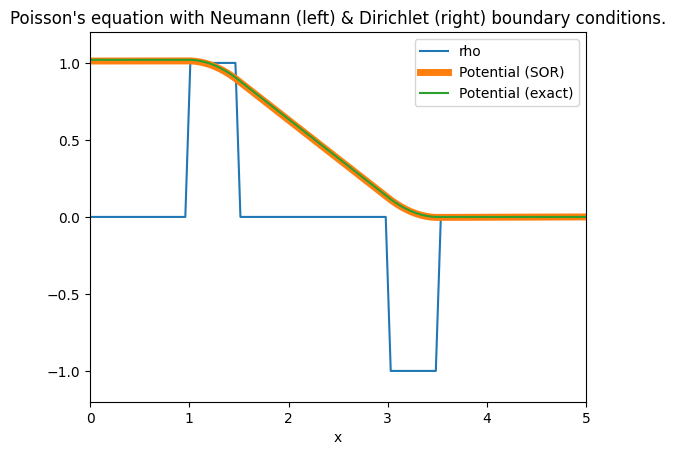

In [ ]:
tolerance = 1.0e-5
max_iter = 15000
omega = 1.8
dirichlet_boundary_right = 0.0 # try for instance -0.5 or 0.3 (note that the solver may not converge)
do_poisson_neumann_dirichlet_SOR_compiled_test(tolerance, max_iter, omega, dirichlet_boundary_right)

# Exercise 1 : A 1D FFT-based Poisson solver
Write an FFT-based solver that solves Poisson's equation in 1D by completing the code in `poisson_fft`.

In Fourier space, the Poisson's equation is extremely simple:

$ \hat{\phi}(k)  = \dfrac{\hat{\rho}(k)}{k^2} $

When you are done, run the code blocks below to test your implementation.

Note: for 1D Fourier transform use `np.fft.fft` and `np.fft.ifft`. Use `np.fft.fftfreq` to compute the frequencies (remember that numpy stores the 0th frequency in the first position).

In [ ]:
def poisson_fft (rho, dx):
    """
    This is a Poisson solver based on the FFT method that enforces periodic boundary conditions.
    It accepts as an input the charge density rho, and it returns the potential phi.

    Parameters
    ----------
    rho : array of floats
        N-components vector of the density rho.
    dx : float
        the spatial resolution

    Returns
    -------
    phi : array of floats
        the computed potential
    """

    Nx = rho.shape[0]

    ############# YOUR CODE HERE! #####
    phi = np.zeros(Nx)
    phi_hat = np.zeros(Nx).astype(complex)
    rho_hat = np.fft.fft(rho)

    k = 2.0*np.pi*np.fft.fftfreq(Nx,dx)

    phi_hat[1:] = rho_hat[1:]/(k[1:]**2)

    phi = np.real(np.fft.ifft(phi_hat))
    ###################################

    return phi

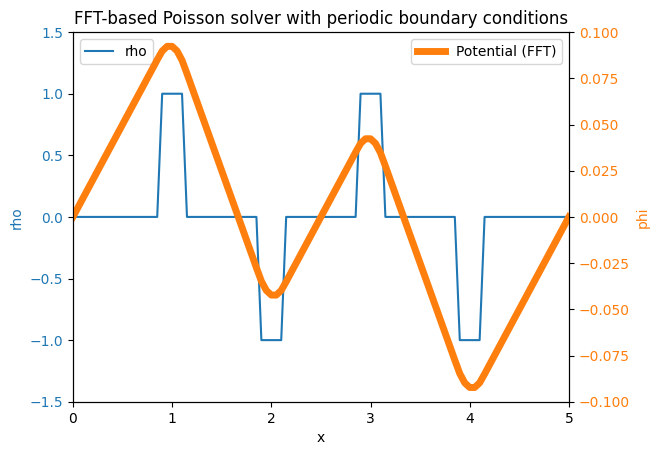

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def do_poisson_1D_fft_test ():
    """
    Test the 1D Poisson solver poisson_fft
    """

    # Define the simulation domain
    N = 101
    L = 5.0
    x = np.linspace(0, L, N)
    dx = L/(N-1)
    ##################

    # Initialize the charge density
    x0 = 1
    x1 = 1.5
    x2 = 3.5
    x3 = 4.0
    xl = np.array([1.0,2.0,3.0,4.0])
    xr = np.array([1.25, 2.25, 3.25, 4.25])
    xl = xl - 0.125
    xr = xr - 0.125
    charge = [1,-1,1,-1]
    rho = np.zeros(N)
    for i in range(4):
        rho = rho + charge[i]*(x > xl[i])*(x < xr[i])
    ##################

    # compute the potential
    phi = np.zeros(N)
    phi[:-1] = poisson_fft (rho[:-1],dx)
    phi[-1] = phi[0] # why this passage?
    ###################################

    fig, ax1 = plt.subplots()

    ax1.set_title("FFT-based Poisson solver with periodic boundary conditions")

    ax1.plot(x, rho, label="rho", color="tab:blue")

    ax1.set_xlim(0,L)
    ax1.set_ylim(-1.5,1.5)
    ax1.set_xlabel("x")
    ax1.set_ylabel('rho', color="tab:blue")
    ax1.tick_params(axis='y', labelcolor="tab:blue")
    ax1.legend(loc=2)

    ax2 = ax1.twinx()

    ax2.plot(x, phi, label="Potential (FFT)", linewidth=5, color="tab:orange")


    ax2.set_ylim(-0.1,0.1)
    ax2.set_ylabel('phi', color="tab:orange")
    ax2.tick_params(axis='y', labelcolor="tab:orange")
    ax2.legend(loc=0)

do_poisson_1D_fft_test ()

# Exercise 2: Lagrangian interpolation
Given a set of N+1 coordinates $(x_0, y_0), (x_1, y_1), (x_2, y_2),\ldots ,(x_{N}, y_{N})$, we can compute the Nth-order Lagrange interpolating Polynomial as follows:

$L_N(x) = \sum_{i=0}^{N} y_i \prod_{j = 0, j \neq i }^{N} \dfrac{x - x_j}{x_i - x_j}$

This polynomial satisfies $L_N(x_i) = y_i$ for $i = 0,1,2,3,\ldots,N$.

For this exercise, complete the function below to return the value of $L_N(x)$ (computed using `x0`, `x1`... and `y0`, `y1`...) at the point `x_interp`. Run the block `test_lagrange` to check the result. The test cases are:
- 4 points sampled from a cubic polynomial (the Lagrange interpolating Polynomial should coincide exactly with the curve)
- 7 points samples from a Runge function (see [Runge's phenomenon](https://en.wikipedia.org/wiki/Runge%27s_phenomenon) and [Witch of Agnesi](https://en.wikipedia.org/wiki/Witch_of_Agnesi))

If you have some additional time, try changing the `Nsampling = 7` line in `lagrange_do_test_2` to increase the amount of sampling points used to interpolate the Runge function.

In [ ]:
def lagrange(xs, ys, x_interp):
    """
    This method computes the N-th order Lagrange polynomial L_N using the N points
    (xs[i], ys[i]) and returns the value of L_N in x_interp.

    Parameters
    ----------
    xs : a float array
        the x coordinates of the points to interpolate
    ys : a float array
        the y coordinates of the points to interpolate
    x_interp : a float array
        values where the interpolating polynomial L_N has to be calculated

    Returns
    -------
    res : the values of L_N computed in x_interp
    """

    N = xs.shape[0]
    assert (ys.shape[0] == N)

    res = 0.0

    #### YOUR CODE HERE ###
    for i in range(N):
        prod=ys[i]
        for j in list([*range(i), *range(i+1,N)]):
         prod= prod*(x_interp-xs[j])/(xs[i]-xs[j])
        res = res + prod
        pass

    # note : (x_interp - xs[j]) is automatically transformed
    #        into the vector (x_interp[0] - xs[j], x_interp[1] - xs[j], ...)
    ########################

    return res

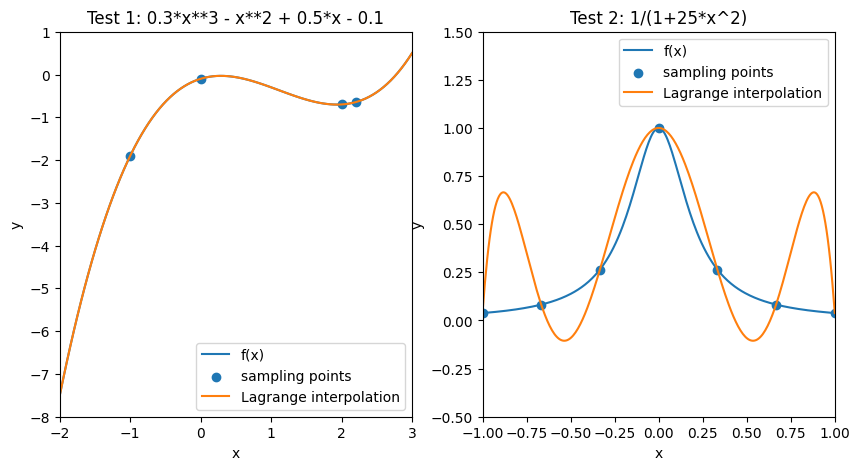

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def lagrange_do_test_1(ax):

    f = lambda x : 0.3*x**3 - x**2 + 0.5*x - 0.1

    xs = np.array([-1.0, 0.0, 2.0, 2.2])
    ys = f(xs)

    xhr = np.linspace(-2.0,3.0,100)
    yhr = f(xhr)

    ax.set_title("Test 1: 0.3*x**3 - x**2 + 0.5*x - 0.1")
    ax.plot(xhr, yhr, label="f(x)")
    ax.scatter(xs, ys, label="sampling points")
    yl = lagrange(xs, ys, xhr)
    ax.plot(xhr, yl, label="Lagrange interpolation")

    ax.set_xlim(-2.0, 3.0)
    ax.set_ylim(-8.0, 1.0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.legend()

def lagrange_do_test_2(ax):

    f = lambda x : 1.0/(1.0 + 25*x*x)

    Nsampling = 7

    xs = np.linspace(-1.0,1.0,Nsampling)
    ys = f(xs)

    xhr = np.linspace(-1.0,1.0,300)
    yhr = f(xhr)

    ax.set_title("Test 2: 1/(1+25*x^2)")
    ax.plot(xhr, yhr, label="f(x)")
    ax.scatter(xs, ys, label="sampling points")
    yl = lagrange(xs, ys, xhr)
    ax.plot(xhr, yl, label="Lagrange interpolation")

    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.legend()

def test_lagrange():
    """
    This function tests the lagrange method
    """
    fig, axs = plt.subplots(1,2,figsize=(10,5))

    lagrange_do_test_1(axs[0])
    lagrange_do_test_2(axs[1])

    plt.show()

test_lagrange()

# Exercise 3: numerical integration with the trapezoidal rule

Numerical integration with the trapezoidal rule consists in approximating the integral $\int_{a}^{b} f(x) dx$ of a function sampled at $N+1$ points $x_0, x_1, \ldots, x_{N}$ with:

$\int_{a}^{b} f(x) dx \approx \sum_{i=0}^{N-1} \dfrac{f(x_{k+1}) + f(x_{k})}{2} (x_{k+1}-x_{k})$

Complete the code in the function `trapz` to implement such numerical integration technique. Then, run the code below to test how good the method is with the [Sophomore's dream integral](https://en.wikipedia.org/wiki/Sophomore%27s_dream).

In [ ]:
def trapz (xk, fk):
    """
    This method computes the numerical integral of the function f
    sampled at N+1 points x_k using the trapezoidal rule.

    Parameters
    ----------
    xk : a float array
        the sampling points
    fk : a float array
        the values of the function f at the sampling points

    Returns
    -------
    res : the integral computed with the trapezoidal rule
    """

    #### YOUR CODE HERE ###
    res = 0.0
    for i in range(xk.shape[0]-1):
        res = res + (fk[i]+fk[i+1])/2.0*(xk[i+1]-xk[i])
    #######################
    # res = 0.5* np.dot(xk[1:]-xk[:], fk[])
    return res

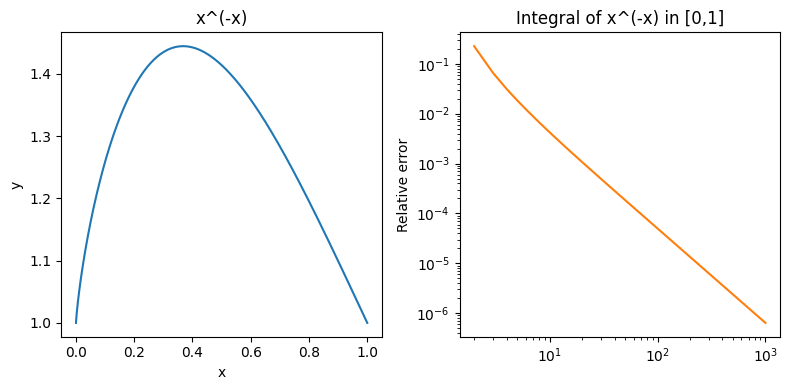

In [ ]:
def test_trapz ():

    fig, axs = plt.subplots(1,2,figsize=(8,4))

    N = np.array(range(2,1001,1))

    ff = lambda x : np.pow(x,-x)

    val = []
    xmin = 0.0
    xmax = 1.0
    for n in N:
        xx = np.linspace(xmin,xmax, n)
        yy = ff(xx)
        val.append(trapz (xx, yy))

    xhr = np.linspace(xmin, xmax, 1000)
    yhr = ff(xhr)
    axs[0].plot(xhr, yhr)

    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")
    axs[0].set_title("x^(-x)")

    sol = 1.29128599706266
    axs[1].loglog(N, np.abs((np.array(val)-sol)/sol), c="tab:orange")

    axs[1].set_label("Number of points")
    axs[1].set_ylabel("Relative error")
    axs[1].set_title("Integral of x^(-x) in [0,1]")

    plt.tight_layout()

test_trapz()


# Exercise 4: a tridiagonal solver
Solving a linear system of equations $A \mathbf{x} = \mathbf{d}$ is very easy when $A$ is a tridiagonal matrix:

$
A =
\begin{pmatrix}
b_0 & c_0 &     &        &         &           & \\
a_1 & b_1 & c_1 &        &         &           & \\
    & a_2 & b_2 & c_2    &         &           & \\
    &     & a_3 & b_3    & c_3     &           & \\
    &     &     & \ddots & \ddots  & \ddots    & \\  
    &     &     &        & a_{N-2} &   b_{N-2} & c_{N-2} \\  
    &     &     &        &         &   a_{N-1} & b_{N-1} \\  
\end{pmatrix}
$

Indeed, by performing Gaussian elimination in a forward pass we can define the following auxiliary quantities:

$
c^\prime_i =
\begin{cases}
      c_0/b_0 & i = 0 \\
      c_i/(b_i - a_ic^\prime_{i-1}) & i > 0
\end{cases}
$

and

$
d^\prime_i =
\begin{cases}
      d_0/b_0 & i = 0 \\
      (d_i - a_i d^\prime_{i-1})/(b_i - a_ic^\prime_{i-1}) & i > 0
\end{cases}
$

Then, the solution is simply computed by back substitution:

$
\begin{cases}
x_{N-1} = d^\prime_{N-1}\\
x_i = d^\prime_{i} - c^\prime_i x_{i+1} \\
\ldots \\
x_0 = d^\prime_{0} - c^\prime_0 x_{1}
\end{cases}
$

This method is very fast ( O(N) ) and it is known as [Thomas algorithm](https://en.wikipedia.org/wiki/Tridiagonal_matrix_algorithm).
Complete the code below in the function `tridiag` to implement the Thomas algorithm and test it by running `do_test_tridiag`.
Note that the method accepts three vectors of size N for the coefficients of the tridiagonal matrix, but the first element of the lower diagonal and the last element of the upper diagonal are ignored.

Note: if you have some additional time, you can try to use it to implement a 1D Poisson solver with Dirichlet boundary conditions.

In [ ]:
@nb.jit
def tridiag(a,b,c,d):
    """
    This method solves the tridiagonal system Ax = d,
    where b is the diagonal vector, a is the lower diagonal,
    and c is the upper diagonal.
    Note that the method accepts three vectors of size N for
    the coefficients of the tridiagonal matrix,
    but the first element of the lower diagonal a
    and the last element of the upper diagonal c are ignored.

    Parameters
    ----------
    a : a float array of size N
        the coefficients in the lower diagonal. The first element a[0] is ignored
    b : a float array of size N
        the coefficients in the diagonal.
    c : a float array of size N
        the coefficients in the upper diagonal. The last element c[N-1] is ignored
    d : a float array of size N
        the components of the vector d

    Returns
    -------
    x : the solution of the linear system Ax=d
    """

    N = b.shape[0]
    assert (a.shape[0] == N)
    assert (c.shape[0] == N)
    assert (d.shape[0] == N)

    cprime = np.zeros(N)
    dprime = np.zeros(N)
    x = np.zeros(N)

    cprime[0] = c[0]/b[0]
    dprime[0] = d[0]/b[0]

    #### YOUR CODE HERE ###
    for i in range(1,N):
        cprime[i] = c[i]/(b[i]-a[i]*cprime[i-1])
        dprime[i] = (d[i]-a[i]*dprime[i-1])/(b[i]-a[i]*cprime[i-1])
        pass

    x[-1]=dprime[-1]

    for i in range(N-2,-1,-1): #goes from N-2 to 0 backwards
        x[i]=dprime[i]-cprime[i]*x[i+1]
        pass

    #######################

    return x

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def do_test_tridiag():

    N = 10
    a = 1 + 0.2*(np.random.rand(N-1) - 0.5)
    b = -2 + 0.4*(np.random.rand(N) - 0.5)
    c = 1 + 0.2*(np.random.rand(N-1) - 0.5)
    d = 2*(np.random.rand(N) - 0.5)

    a = np.concatenate([[np.nan], a])
    c = np.concatenate([c, [np.nan]])

    x = tridiag(a,b,c,d)

    A = np.diag(a[1:], -1) + np.diag(b, 0) + np.diag(c[:-1], 1)
    xex = np.linalg.solve(A, d)

    print ("Your solution    : ", x, "\n")
    print ("Numpy's solution : ", xex, "\n")
    print ("Discrepancy      : ", x-xex, "\n")

    if (np.allclose(x, xex)):
        print("Success!")
    else :
        print("Fail!")

do_test_tridiag()

Your solution    :  [-0.08955608  0.0552745   0.62263584  0.65200864  0.81687139  0.87552199
  0.12329351 -0.38285456 -0.33428029 -0.0690604 ] 

Numpy's solution :  [-0.08955608  0.0552745   0.62263584  0.65200864  0.81687139  0.87552199
  0.12329351 -0.38285456 -0.33428029 -0.0690604 ] 

Discrepancy      :  [-3.74700271e-16 -6.93889390e-16 -8.88178420e-16 -1.22124533e-15
 -1.66533454e-15 -1.88737914e-15 -1.76247905e-15 -1.49880108e-15
 -9.99200722e-16 -4.99600361e-16] 

Success!


# Exercise 5: cubic splines
Computing a periodic cubic spline is admittedly bit tedious, but in this exercise your task is just that!
Let's assume that we have $n+1$ points

$(x_0, y_0), (x_1, y_1), \ldots, (x_n, y_n)$

and that $y_0 = y_n$ because of periodicity.

Our cubic spline is defined piecewise with a family of $n$ third-degree polynomials $P_i(x)$ (each defined in the interval $ x_i \leq x < x_{i+1}$), that can be written as follows:

$P_i(x) = \frac{M_i}{6} \frac{(x_{i+1}-x)^3}{h_i} + \frac{M_{i+1}}{6} \frac{(x - x_i)^3}{h_i} + C_i (x - x_i) + D_i $

where:

$C_i = \frac{\Delta y_i}{h_i} + \frac{h_i}{6} (M_i - M_{i+1}) $

$D_i = y_i - \frac{1}{6} M_i h_i^2$

$h_i = x_{i+1} - x_{i}$

$\Delta y_i = y_{i+1} - y_{i}$

Imposing periodic boundary conditions leads to:

$M_0 = M_n$

and

$A \mathbf{M} = \mathbf{d}$

where:

$
A =
\begin{pmatrix}
2   & \lambda_1 &     &        &         &      \mu_1 & \\
\mu_2 & 2  & \lambda_2 &        &         &           & \\
    & \mu_3 & 2  & \lambda_3    &         &           & \\
    &     & \mu_4 & 2     & \lambda_4     &           & \\
    &     &     & \ddots & \ddots  & \ddots    & \\  
    &     &     &        & \mu_{n-1} &   2       & \lambda_{n-1} \\  
\lambda_{n}    &     &     &        &         &   \mu_{n} & 2 \\  
\end{pmatrix}
$

and

$
\mathbf{M} =
\begin{bmatrix}
M_1 \\
M_2 \\
\vdots \\
M_n
\end{bmatrix}
$

$
\mathbf{d} =
\begin{bmatrix}
d_1 \\
d_2 \\
\vdots \\
d_n
\end{bmatrix}
$

where for $ 1 \leq i < n$:

$\mu_i = \frac{h_{i-1}}{h_i + h_{i-1}}$

$\lambda_i = \frac{h_{i}}{h_i + h_{i-1}}$

$d_i = \frac{6}{h_i + h_{i-1}} \left({ \frac{\Delta y_i}{h_i} - \frac{\Delta y_{i-1}}{h_{i-1}} }\right)$

and for $i = n$:

$\mu_n = \frac{h_{n-1}}{h_0 + h_{n-1}}$

$\lambda_n = \frac{h_{0}}{h_0 + h_{n-1}}$

$d_n = \frac{6}{h_0 + h_{n-1}} \left({ \frac{\Delta y_0}{h_0} - \frac{\Delta y_{n-1}}{h_{n-1}} }\right)$

Now, we can choose an arbitrary non-zero parameter $\gamma$ (just avoid setting a diagonal element to zero, e.g., $\gamma = - 2$ is fine) and we can re-write $A$ as follows:

$A = B + \mathbf{u} \mathbf{v}^T$

where B is tridiagonal

$
B =
\begin{pmatrix}
2 - \gamma  & \lambda_1 &     &        &         &     & \\
\mu_2 & 2  & \lambda_2 &        &         &           & \\
    & \mu_3 & 2  & \lambda_3    &         &           & \\
    &     & \mu_4 & 2     & \lambda_4     &           & \\
    &     &     & \ddots & \ddots  & \ddots    & \\  
    &     &     &        & \mu_{n-1} &   2       & \lambda_{n-1} \\  
    &     &     &        &         &   \mu_{n} & 2 - \frac{\lambda_n \mu_1}{\gamma} \\  
\end{pmatrix}
$

and

$
\mathbf{u} =
\begin{bmatrix}
\gamma \\
0 \\
\vdots \\
0 \\
\lambda_n
\end{bmatrix}
$

$
\mathbf{v} =
\begin{bmatrix}
1 \\
0 \\
\vdots \\
0 \\
\mu_1/\gamma
\end{bmatrix}
$

Finally, we can compute the solution for $\mathbf{M}$ as follows:

$B \mathbf{p} = \mathbf{d}$

$B \mathbf{q} = \mathbf{u}$

$\mathbf{M} = \mathbf{p} - \mathbf{q} \frac{\mathbf{v} \cdot \mathbf{p} }{1 + \mathbf{v} \cdot \mathbf{q}}$

Complete the function `periodic_cubic_spline` and run the test below to check your implementation!

In [ ]:
@nb.njit
def periodic_cubic_spline(x, y, x_interp):
    """
    This method computes the periodic cubic spline S passing through the points
    (x[i], y[i]) and returns the value of S(x) in x_interp. Note that y[0] = y[-1] is assumed.

    Parameters
    ----------
    x : a float array
        the x coordinates of the points to interpolate
    y : a float array
        the y coordinates of the points to interpolate
    x_interp : a float array
        values where the interpolating spline S(x) has to be calculated

    Returns
    -------
    res : the values of S(x) computed in x_interp
    """

    assert (x.shape[0] == y.shape[0])

    # number of intervals
    n = x.shape[0] - 1

    # h and dy vectors
    h = np.diff(x)
    dy = np.diff(y)

    # arbitrary gamma parameter
    gamma = -2.0

    # diagonals of the matrix B
    ll = np.zeros(n)
    mu = np.zeros(n)

    #### YOUR CODE HERE ###
    for i in range(n-1):
      mu[i] = h[i]/(h[i]+h[i+1])
      ll[i] = h[i+1]/(h[i]+h[i+1])
    # .. should we do something for the last element ?
    mu[n-1]= h[n-1]/(h[n-1]+h[0])
        # tricky: note that the first element of mu is mu_1 !
        # ...
    # .. should we do something for the last element ?
    ll[n-1]= h[0]/(h[n-1]+h[0])
    #######################

    diag = 2*np.ones(n)

    #### YOUR CODE HERE ###
    diag[0] -= gamma
    diag [n-1] -= ll[n-1]*mu[0]/gamma
    #######################

    # d vector
    d = np.zeros(n)

    #### YOUR CODE HERE ###
    for i in range(n-1):
      d[i] = 6.0/(h[i]+h[i-1])*(dy[i]/h[i] - dy[i-1]/h[i-1])
    # .. should we do something for the last element ?
    #######################
    d[n-1] = 6.0/(h[0]+h[i-1])*(dy[0]/h[0] - dy[i-1]/h[i-1])
    # u and v vectors
    u = np.zeros(n)
    v = np.zeros(n)

    #### YOUR CODE HERE ###
    u[0] = gamma
    u[-1] = ll[n-1]
    v[0] = 1
    v[-1]= mu[0]/gamma
    #######################

    # solve the two tri-diagonal systems

    #### YOUR CODE HERE ###
    p = tridiag(mu,diag,ll,d)
    q = tridiag(mu,diag,ll,u)
    #######################

    # find M
    M = np.zeros(n+1)

    #### YOUR CODE HERE ###
    temp_M =p-q*(np.dot(v,p))/(1+np.dot(v,q)) # first we compute [M_1, M_2, ... M_n]
    M[1:] = temp_M # then we create the vector [M_n, M_1, M_2, ... M_n]
    M[0]=M[-1]
    #######################

    # compute the coefficients C and D
    A = M[:-1]/6.0/h
    B = M[1:]/6.0/h
    C = dy/h - h*(M[1:]-M[:-1])/6.0
    D = y[:-1]- M[:-1]*h**2/6.0

    # compute the indices of the points at the left of the points in x_interp
    # note that x_interp is folded back in the interval [x[0], x[-1])
    L = x[-1] - x[0]
    x_interp = x_interp - L*np.floor((x_interp-x[0])/L)
    idx = np.searchsorted(x, x_interp, side='right') - 1

    # compute the spline at the points x_interp
    y_interp = A[idx]*(x[idx+1]-x_interp)**3 + B[idx]*(x_interp - x[idx])**3 + C[idx]*(x_interp-x[idx]) + D[idx]

    return y_interp


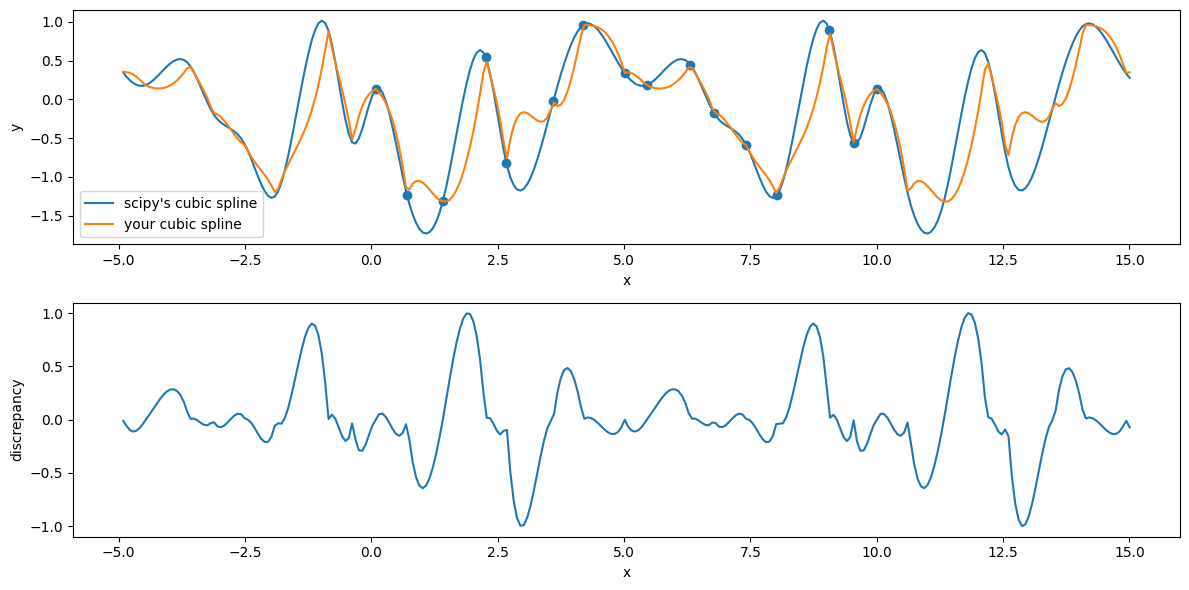

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def test_periodic_cubic_spline():

    #prepare the data points
    N = 15
    xmin_i = 0
    xmax_i = 10.0
    xx = np.linspace(xmin_i, xmax_i, N+1) + 0.4*np.random.rand(N+1)
    xmin = np.min(xx)
    xmax = np.max(xx)
    yy = 3.0*(np.random.rand(N+1)-0.5)
    yy[-1] = yy[0]

    #prepare the points where the spline has to be computed
    Nhr = 300
    ll = 5.0
    x_interp = np.linspace(xmin-ll, xmax+ll, Nhr)

    # compute the cubic spline
    y_interp = periodic_cubic_spline(xx, yy, x_interp)

    # compare with the scipy implementation
    cs = sci.interpolate.CubicSpline(xx, yy, bc_type='periodic')
    y_interp_scipy = cs(x_interp)

    fig, axs = plt.subplots(2,1, figsize=(12,6))

    axs[0].scatter(xx, yy)
    axs[0].plot(x_interp, y_interp_scipy, label="scipy's cubic spline")
    axs[0].plot(x_interp, y_interp, label="your cubic spline")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")
    axs[0].legend()

    axs[1].plot(x_interp, y_interp_scipy-y_interp)
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("discrepancy")

    plt.tight_layout()

test_periodic_cubic_spline()

## Exercise 6: a Vlasov-Poisson solver

We are almost done! Your last task for today is to complete the `advect_v` and the `compute_rho` functions below to complete a Vlasov-Poisson solver. Note, this particular solver is designed to evolve only the electron distribution function, while the ion density is set once at the beginning of the simulation is such a way that the initial system is electrically neutral (this corresponds to the "immobile ions" approximation).

Hint: use `advect_x` as a source of inspiration to implement `advect_v`

Hint: consider the `np.trapezoid` function to compute the integral required to calculate the charge density. You are encouraged to have a look at the documentation.


In [ ]:
help(np.trapezoid)

In [ ]:
def advect_x (xx, vx, f, dt):
    """
    This function perform the advection of the distribution function along x

    Parameters
    ----------
    xx : array of floats
        Nx-components vector of spatial coordinates
    vx : array of floats
        Nv-components vector of velocities
    f : 2d-array of floats
        (Nv, Nx) matrix containing the distribution function
    dt : float
        timestep
    """
    Nv = vx.shape[0]

    # We can't update f in place, so we generate a matrix
    # with the same size
    fn = np.zeros(f.shape)

    #For each velocity grid point (except the boundary, which we won't touch)
    for i in range(2, Nv-1):
        # We compute the displacement
        displacement = vx[i]*dt
        # and we compute the positions of the grid points at the previous timestep
        x_interp = xx[:-1] - displacement

        # finally, we interpolate the new values of the distribution function at
        # the spatial grid points (note that we don't compute anything for the right-most
        # boundary, due to Periodic Boundary Conditions).
        #
        # np.ascontiguousarray may be necessary to call a function compiled with numba,
        # since functions requiring contiguous arrays may be called. It is actually
        # not strictly needed here, but it is required in advect_v
        fn[i, :-1] = periodic_cubic_spline(xx, np.ascontiguousarray(f[i,:]), x_interp)

    # We copy the new distribution function into the old one
    f[:,:] = fn[:,:]
    # We enforce Periodic Boundary Conditions
    f[:,-1] = f[:,0]

def advect_v (xx, vx, f, q_m, E, dt):
    """
    This function perform the advection of the distribution function along vx

    Parameters
    ----------
    xx : array of floats
        Nx-components vector of spatial coordinates
    vx : array of floats
        Nv-components vector of velocities
    f : 2d-array of floats
        (Nv, Nx) matrix containing the distribution function
    q_m : float
        the charge over mass ratio of the species of the distribution function f
    E : array of floats
         Nx-components vector containing the electric field at the spatial grid points
    dt : float
        timestep
    """
    Nx = xx.shape[0]
    Nv = vx.shape[0]

    # We can't update f in place, so we generate a matrix
    # with the same size
    fn = np.zeros(f.shape)

    #### YOUR CODE HERE ###
    # note: we don't update points on the right-most boundary due to pbc
    for i in range(Nx-1):
        #displacement = ?
        #v_interp = ? (note: don't touch the first and the last grid points)
        #fn[1:-1, i] = ?
        pass
    ########################

    # We copy the new distribution function into the old one
    f[:,:] = fn[:,:]
    # We enforce Periodic Boundary Conditions
    f[:,-1] = f[:,0]

def compute_rho (rho0, f, q, dv):
    """
    This method computes the charge density, using the background density rho0,
    the distribution function f, the charge of the species of f: q and the spacing
    of the velocity grid dv.

    Parameters
    ----------
    rho0 : array of floats
        Nx-components vector containing the background density (ions)
    f : 2d-array of floats
        (Nv, Nx) matrix containing the distribution function
    q : float
        charge of the particles of the distribution function f
    dv : float
        spacing of the velocity grid

    Returns
    -------
    rho : array of floats
        Nx-components vector containing the charge density
    """

    #### YOUR CODE HERE ###
    rho = rho0 # + ? (warning: the velocity axis is the 0-th one!)
    ########################

    #Enforce periodic boundary conditions
    rho[-1] = rho[0]
    return rho

def compute_E (rho, dx):
    """
    This method computes the electric field using the charge density and the
    spacing of the spatial grid

    Parameters
    ----------
    rho : array of floats
        Nx-components vector containing the charge density
    dx : float
        spacing of the spatial grid

    Returns
    -------
    E : array of floats
        Nx-components vector containing the electric field
    """
    E = np.zeros(rho.shape[0])

    # Use the poisson solver to compute the potential
    phi = poisson_fft (rho[:-1], dx)

    # Compute E as the centered derivative of the potential
    E[:-1] = -0.5*(np.roll(phi,-1) - np.roll(phi,1))/dx

    # Enforce periodic boundary conditions
    E[-1] = E[0]
    return E

def do_vlasov_electrons_only(L, v_max, Nx, Nv, f_init_function, dt, steps, record_distrib_function = False,  record_distrib_function_freq = 100):
    """
    This method simulates the Vlasov-Poisson equation only for the electrons
    (ions are an immobile, neutralizing, background)

    Parameters
    ----------
    L : float
        size of the spatial grid
    v_max : float
        maximum velocity
    Nx : int
       number of spatial grid points
    Nv : int
       number of velocity grid points
    f_init_function : function (x, vx)
       function of position and velocity to initialize the distribution function
    dt : float
        timestep
    steps: integer
        number of time steps
    record_distrib_function : bool
        flag to enable the recording of the distribution function every record_distrib_function_freq
    record_distrib_function_freq : int
        if record_distrib_function is True, the method returns the distribution function every record_distrib_function_freq

    Returns
    -------
    rho : array of floats
        Nx-components vector containing the charge density
    """

    # compute the x and vx coordinates:
    xx = np.linspace(0.0, L, Nx)
    vx = np.linspace(-v_max, v_max, Nv)

    # compute dx and dv
    dx = L/(Nx - 1)
    dv = 2*v_max/(Nv - 1)

    # compute coordinate matrices from coordinate vectors
    XX, VX = np.meshgrid(xx, vx)

    # initialize the distribution function
    f0 = f_init_function(XX, VX)

    # initialize the electric field
    E = np.zeros(Nx)

    # we are dealing with electrons
    q = -1.0
    m = 1.0
    q_m = q/m

    # compute the initial ion density so that it is equal to the initial electron density
    rho0 = -q*(np.trapezoid(f0, dx=dv, axis=0))

    # create a deep copy of the distribution function f
    f = np.copy(f0)

    # advect along x by dt/2
    advect_x(xx, vx, f, dt*0.5)

    all_data = []

    energy_E = []

    # perform the simulation
    for st in tqdm(range(steps)):
        rho = compute_rho(rho0, f, q, dv)
        E = compute_E(rho, dx)
        energy_E.append(np.sum(E**2))
        advect_v(xx, vx, f, q_m, E, dt)
        advect_x(xx, vx, f, dt)
        if record_distrib_function and ( st % record_distrib_function_freq == 0 ) :
            all_data.append(np.copy(f))

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    ax[0].imshow(f, extent=[0.0, L, -v_max, v_max], vmin=0, vmax=np.max(f0))
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("vx")
    ax[0].set_title("f(x,vx)")

    ax[1].semilogy(energy_E)
    ax[1].set_xlabel("steps")
    ax[1].set_ylabel("Ex energy [arb.units]")
    ax[1].set_ylim(1e-2,1e2)

    plt.tight_layout()

    return all_data

def test_vlasov_two_stream():
    """
    Test the Vlasov-Poisson code for a two-stream instability scenario
    """
    L  = 12.0
    v_max = 2.0
    Nx = 300
    Nv = 2*150+1

    dx = L/(Nx - 1)
    dt = 0.8*dx/v_max

    v1 = 0.5
    v2 = -0.5
    v_sigma = 0.05
    n_0 = 1.0
    k = 2.0*np.pi/6.0
    amp = 0.1

    energy_E = []

    def f_init_function(x, vx) :
        n = n_0 * (1 + amp*np.sin(k*x))
        den = 2.0*v_sigma**2
        vterm = (0.5/np.sqrt(2 *np.pi)/v_sigma) * (np.exp(-(vx - v1)**2/den) + np.exp(-(vx - v2)**2/den))
        return n*vterm

    steps = 600

    do_vlasov_electrons_only(L, v_max, Nx, Nv, f_init_function, dt, steps)


test_vlasov_two_stream()

In [ ]:
from matplotlib import animation

def animation_vlasov_two_stream():
    """
    Same as above, but it generates a movie!
    """
    L  = 12.0
    v_max = 2.0
    Nx = 300
    Nv = 2*150+1

    dx = L/(Nx - 1)
    dt = 0.8*dx/v_max

    v1 = 0.5
    v2 = -0.5
    v_sigma = 0.05
    n_0 = 1.0
    k = 2.0*np.pi/6.0
    amp = 0.1

    def f_init_function(x, vx) :
        n = n_0 * (1 + amp*np.sin(k*x))
        den = 2.0*v_sigma**2
        vterm = (0.5/np.sqrt(2 *np.pi)/v_sigma) * (np.exp(-(vx - v1)**2/den) + np.exp(-(vx - v2)**2/den))
        return n*vterm

    steps = 600

    all_data =  do_vlasov_electrons_only(L, v_max, Nx, Nv, f_init_function, dt, steps, record_distrib_function=True, record_distrib_function_freq=1)

    mm = np.max(all_data[0])

    fig, ax = plt.subplots()

    im = plt.imshow(all_data[0], extent=[0,L,-v_max,v_max], vmin=0, vmax=mm)
    plt.xlabel("x")
    plt.ylabel("vx")

    def update(frame):
        im.set_data(all_data[frame])
        return (im)

    ani = animation.FuncAnimation(fig=fig, func=update, frames=steps, interval=30)
    ani.save("res.avi")
    plt.show()

animation_vlasov_two_stream()

# If you have some time

Feel free to experiment with the Vlasov code above! Some ideas:

- Explore how the resolution and the time step affect the result
- Change the initial setup: try a different distribution function (e.g., Langmuir waves)
- Add a total energy diagnostic
- Add a diagnostic of the total integral of the distribution function

Warning: this mini-code is not very robust! Expect some numerical issues, especially if the distribution function is not very smooth.